In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchdiffeq import odeint

In [2]:
def create_A(N):
    A = np.zeros((N, N))
    for i in range(1, N-1):
        A[i, i-1] = 1
        A[i, i] = -2
        A[i, i+1] = 1
    return torch.tensor(A, dtype=torch.float32)

In [3]:
def generate_data(N=50, T=1.0, steps=100):
    x = np.linspace(0, 1, N)
    t = np.linspace(0, T, steps)

    # initial condition (sin)
    u0 = np.sin(np.pi * x)

    A = create_A(N)

    u = [torch.tensor(u0, dtype=torch.float32)]

    dt = t[1] - t[0]

    for _ in range(steps-1):
        u_next = u[-1] + dt * (A @ u[-1])
        u.append(u_next)

    return torch.stack(u), torch.tensor(t, dtype=torch.float32), A

In [4]:
class ODEFunc(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 64),
            nn.Tanh(),
            nn.Linear(64, dim)
        )

    def forward(self, t, u):
        return self.net(u)

In [5]:
class HybridODEFunc(nn.Module):
    def __init__(self, dim, A, lam=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 64),
            nn.Tanh(),
            nn.Linear(64, dim)
        )
        self.A = A
        self.lam = lam

    def forward(self, t, u):
        return self.net(u) + self.lam * (self.A @ u)

In [6]:
def train(model, u_true, t, epochs=200):

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        optimizer.zero_grad()

        u0 = u_true[0]
        u_pred = odeint(model, u0, t)

        loss = torch.mean((u_pred - u_true)**2)

        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:
            print(f"epoch {epoch}, loss: {loss.item():.6f}")

    return model

In [7]:
# generate data
u_true, t, A = generate_data()

dim = u_true.shape[1]

# train neural ODE
print("Training Neural ODE...")
model_neural = ODEFunc(dim)
model_neural = train(model_neural, u_true, t)

# train hybrid model (PINN)
print("\nTraining Physics-Informed Model...")
model_hybrid = HybridODEFunc(dim, A)
model_hybrid = train(model_hybrid, u_true, t)

Training Neural ODE...
epoch 0, loss: 0.017768
epoch 50, loss: 0.000019
epoch 100, loss: 0.000000
epoch 150, loss: 0.000000

Training Physics-Informed Model...
epoch 0, loss: 0.012259
epoch 50, loss: 0.000010
epoch 100, loss: 0.000000
epoch 150, loss: 0.000000


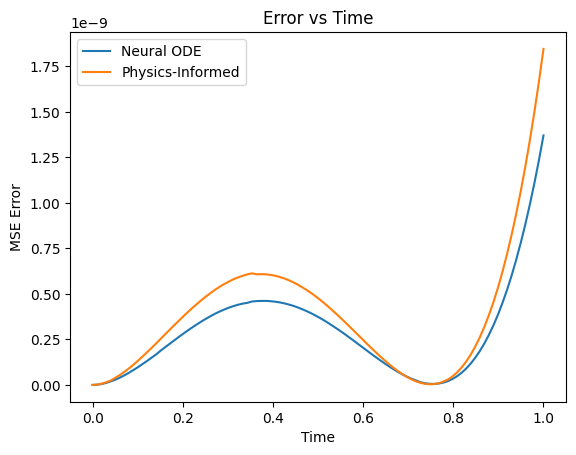

In [8]:
u0 = u_true[0]

u_pred_neural = odeint(model_neural, u0, t).detach()
u_pred_hybrid = odeint(model_hybrid, u0, t).detach()

# compute error
error_neural = torch.mean((u_pred_neural - u_true)**2, dim=1)
error_hybrid = torch.mean((u_pred_hybrid - u_true)**2, dim=1)

# plot error
plt.plot(t, error_neural, label="Neural ODE")
plt.plot(t, error_hybrid, label="Physics-Informed")
plt.legend()
plt.title("Error vs Time")
plt.xlabel("Time")
plt.ylabel("MSE Error")
plt.show()

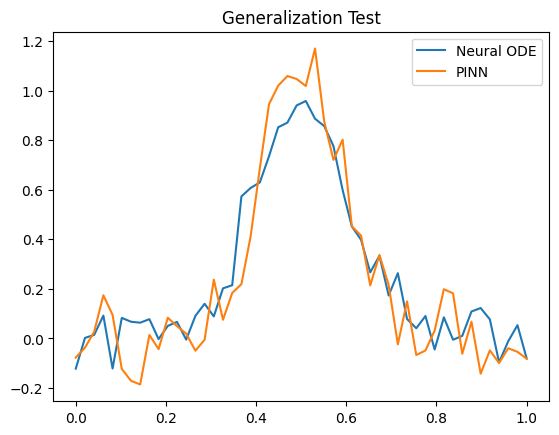

In [9]:
# new initial condition (Gaussian)
x = np.linspace(0, 1, dim)
u0_new = np.exp(-50 * (x - 0.5)**2)
u0_new = torch.tensor(u0_new, dtype=torch.float32)

u_pred_neural = odeint(model_neural, u0_new, t)
u_pred_hybrid = odeint(model_hybrid, u0_new, t)

plt.plot(x, u_pred_neural[-1].detach(), label="Neural ODE")
plt.plot(x, u_pred_hybrid[-1].detach(), label="PINN")
plt.legend()
plt.title("Generalization Test")
plt.show()